In [ ]:
pip install torch pandas scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, roc_curve, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

from sklearn.calibration import calibration_curve
from sklearn.manifold import MDS

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,weather_condition,urban_density,sidewalk_capacity,safety_risk,accessibility
0,0.001455,36.138560,100.000000,75.756150,1
1,0.002301,25.744824,96.783777,91.750797,1
2,0.000040,29.250817,46.777125,99.667612,1
3,0.003700,0.029002,98.166379,65.702376,0
4,0.306264,77.261916,53.011162,87.044901,1


# Helper Functions

In [ ]:
# Function to split features and target
def split_features_target(df, test_size):

  """
  df should contain these columns ['Weather Conditions', 'Road Capacity', 'Urban Density', 'Safety Risk', 'Accessibility']
  """

  cols = df.columns
  print(cols)

  classes = cols[-1:]  # Target is 'Accessibility'
  print(classes)
  features = cols[0:4]  # Select the first 4 features
  print(features)

  X = df[features].values
  Y = df[classes].values

  return train_test_split(X, Y, test_size=test_size)

In [ ]:
def calculate_metrics(y_test, y_pred, y_prob_in_positive_class):

    metrics = {
        'AUC': np.round(roc_auc_score(y_test, y_prob_in_positive_class), 3),
        'Precision': np.round(precision_score(y_test, y_pred), 3),
        'Recall': np.round(recall_score(y_test, y_pred), 3),
        'F1-score': np.round(f1_score(y_test, y_pred), 3),
        'Accuracy': np.round(accuracy_score(y_test, y_pred), 3)
    }

    # Print metrics
    print(f"AUC: {metrics['AUC']}")
    print(f"Precision: {metrics['Precision']}")  # Proportion of true positives of all positive predictions
    print(f"Recall: {metrics['Recall']}")
    print(f"F1-score: {metrics['F1-score']}")
    print(f"Accuracy: {metrics['Accuracy']}")

In [ ]:
x_train, x_test, y_train, y_test = split_features_target(df, 0.40)

Index(['weather_condition', 'urban_density', 'sidewalk_capacity',
       'safety_risk', 'accessibility'],
      dtype='object')
Index(['accessibility'], dtype='object')
Index(['weather_condition', 'urban_density', 'sidewalk_capacity',
       'safety_risk'],
      dtype='object')


In [ ]:
embedding = MDS(n_components=2, normalized_stress='auto')
x_transformed = embedding.fit_transform(x_test)
x_transformed.shape

KeyboardInterrupt: 

# Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lrm = LogisticRegression(penalty="l2").fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
lrm_y_prob = lrm.predict_proba(x_test)
lrm_y_prob

array([[0.75851064, 0.24148936],
       [0.35675897, 0.64324103],
       [0.32246683, 0.67753317],
       ...,
       [0.11915438, 0.88084562],
       [0.01242269, 0.98757731],
       [0.03753714, 0.96246286]])

In [ ]:
lrm_y_prob_in_class_1_given_X = lrm_y_prob[:, 1]
lrm_y_prob_in_class_1_given_X

array([0.24148936, 0.64324103, 0.67753317, ..., 0.88084562, 0.98757731,
       0.96246286])

In [ ]:
lrm_y_pred = lrm.predict(x_test)
lrm_y_pred

array([0, 1, 1, ..., 1, 1, 1])

In [ ]:
calculate_metrics(y_test, lrm_y_pred, lrm_y_prob_in_class_1_given_X)

AUC: 0.913
Precision: 0.847
Recall: 0.895
F1-score: 0.871
Accuracy: 0.835


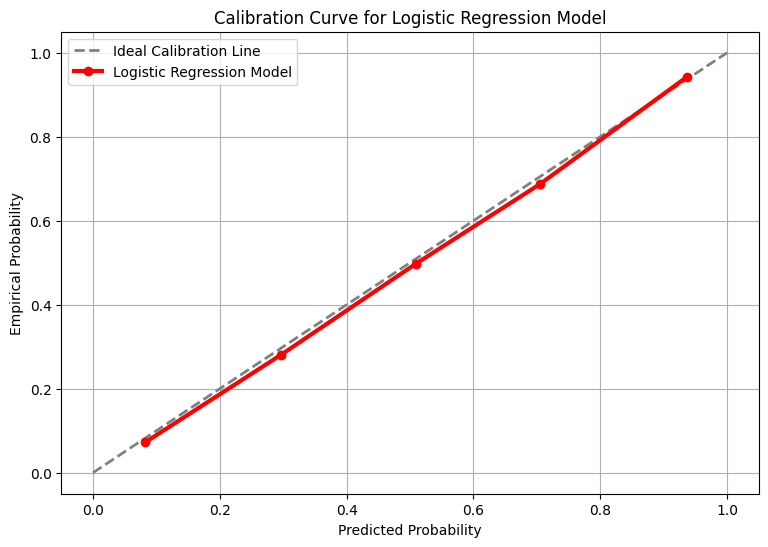

In [ ]:
# Calculate calibration data
prob_true, prob_pred = calibration_curve(y_test, lrm_y_prob_in_class_1_given_X, n_bins=5)

# Plot calibration curve
fig, ax = plt.subplots(figsize=(9, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line", linewidth=2)  # Diagonal ideal line
plt.plot(prob_pred, prob_true, marker='o', label="Logistic Regression Model", color="red", linewidth=3)

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.savefig('lrm_1.png', dpi=300, bbox_inches='tight')
plt.show()

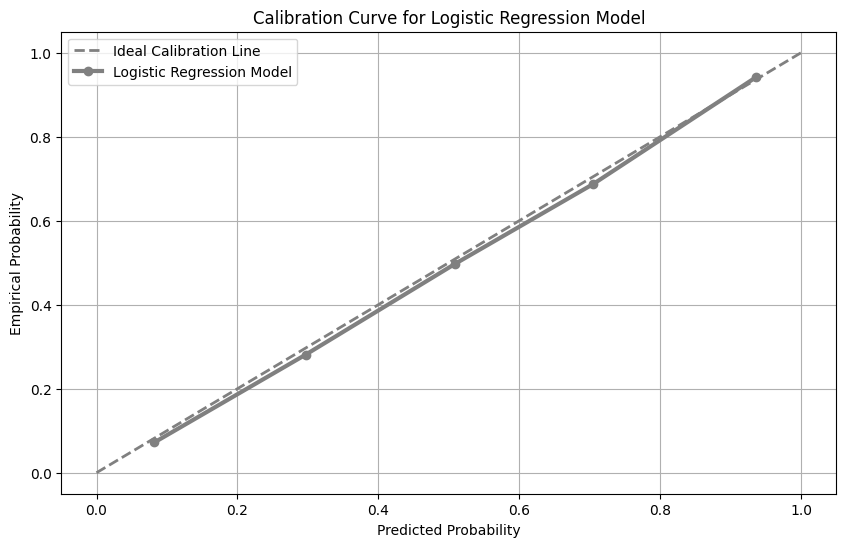

In [ ]:
# Calculate calibration data
prob_true, prob_pred = calibration_curve(y_test, lrm_y_prob_in_class_1_given_X, n_bins=5)

# Plot calibration curve
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line", linewidth=2)  # Diagonal ideal line
plt.plot(prob_pred, prob_true, marker='o', label="Logistic Regression Model", color="grey", linewidth=3)

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.savefig('lrm_1_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
lrm_matcher_f = lambda x, y: 1 if x == y else 0
lrm_matched_ = np.array([lrm_matcher_f(lrm_y_pred[i], y_test[i]) for i in range(len(y_test))])

NameError: name 'x_transformed' is not defined

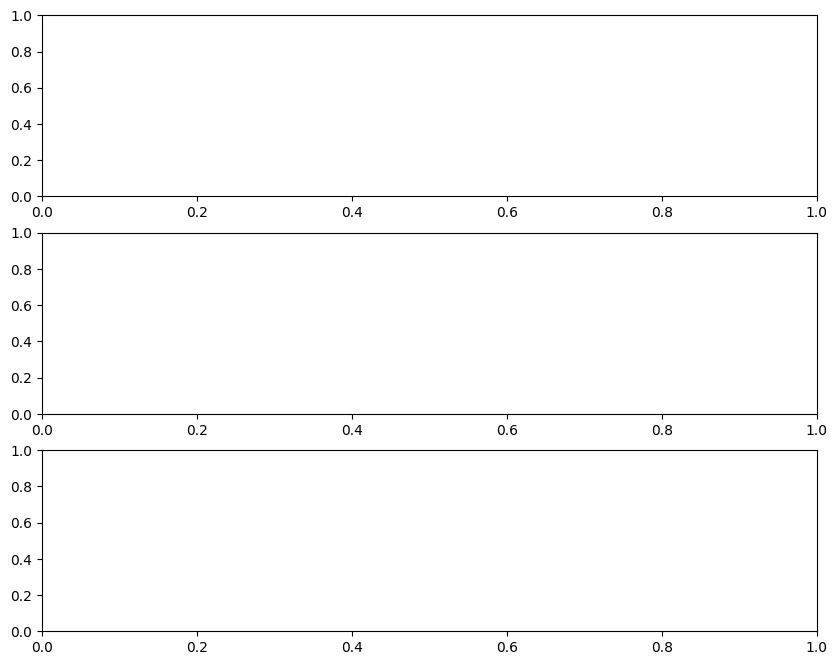

In [ ]:
fig, ax = plt.subplots(nrows=3,figsize=(10,8))
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=y_test.reshape(-1,), ax=ax[0])
ax[0].set_title("Test Data")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=lrm_y_pred.reshape(-1,), ax=ax[1])
ax[1].set_title("Predictions")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=lrm_matched_.reshape(-1,), ax=ax[2], palette="husl") ### Pink points are misclassified
ax[2].set_title("Visualizing Decision")
plt.tight_layout()

In [ ]:
plt.savefig('lrm_1.png', dpi=300, bbox_inches='tight')

# Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)

In [ ]:
gnb = GaussianNB()
gnb.fit(scaled_x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [ ]:
gnb_y_pred = gnb.predict(scaled_x_test)
gnb_y_pred

array([0, 1, 1, ..., 1, 1, 1])

In [ ]:
gnb_y_prob = gnb.predict_proba(scaled_x_test)
gnb_y_prob

array([[0.51902401, 0.48097599],
       [0.34224734, 0.65775266],
       [0.25423976, 0.74576024],
       ...,
       [0.15259123, 0.84740877],
       [0.03255207, 0.96744793],
       [0.06439255, 0.93560745]])

In [ ]:
gnb_y_prob_in_class_1_given_X = gnb_y_prob[:, 1]
gnb_y_prob_in_class_1_given_X

array([0.48097599, 0.65775266, 0.74576024, ..., 0.84740877, 0.96744793,
       0.93560745])

In [ ]:
calculate_metrics(y_test, gnb_y_pred, gnb_y_prob_in_class_1_given_X)

AUC: 0.903
Precision: 0.816
Recall: 0.918
F1-score: 0.864
Accuracy: 0.822


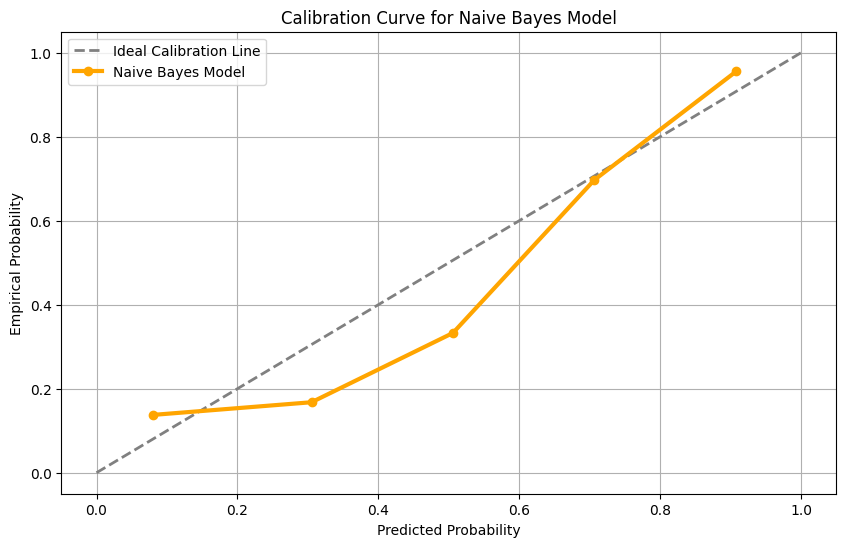

In [ ]:
# Calculate calibration data
prob_true, prob_pred = calibration_curve(y_test, gnb_y_prob_in_class_1_given_X, n_bins=5)

# Plot calibration curve
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line", linewidth=2)  # Diagonal ideal line
plt.plot(prob_pred, prob_true, marker='o', label="Naive Bayes Model", color="orange", linewidth=3)

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Naive Bayes Model")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gnb_matcher_f = lambda x, y: 1 if x == y else 0
gnb_matched_ = np.array([gnb_matcher_f(gnb_y_pred[i], y_test[i]) for i in range(len(y_test))])

NameError: name 'x_transformed' is not defined

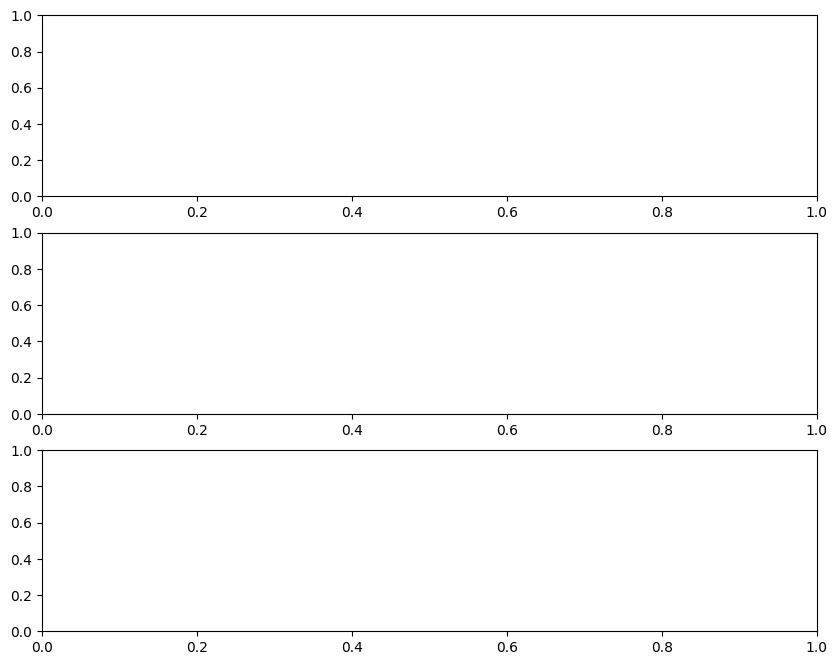

In [ ]:
fig, ax = plt.subplots(nrows=3,figsize=(10,8))
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=y_test.reshape(-1,), ax=ax[0])
ax[0].set_title("Test Data")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=gnb_y_pred.reshape(-1,), ax=ax[1])
ax[1].set_title("Predictions")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=gnb_matched_.reshape(-1,), ax=ax[2], palette="husl") ### Pink points are misclassified
ax[2].set_title("Visualizing Decision")
plt.tight_layout()

In [ ]:
plt.savefig('gnb_1.png', dpi=300, bbox_inches='tight')

# Neural Network

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(scaled_x_train, dtype=torch.float32)
X_test_tensor = torch.tensor(scaled_x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)  # Shape (n_samples, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Shape (n_samples, 1)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [ ]:
# Define the larger neural network
class LargerNN(nn.Module):
    def __init__(self):
        super(LargerNN, self).__init__()
        self.fc1 = nn.Linear(4, 64)    # Increase input layer to 64 neurons
        self.fc2 = nn.Linear(64, 32)   # Second layer with 32 neurons
        self.fc3 = nn.Linear(32, 16)   # Third layer with 16 neurons
        self.fc4 = nn.Linear(16, 1)    # Output layer for binary classification
        self.dropout = nn.Dropout(0.2) # Dropout layer with 20% dropout rate

    def forward(self, x):
        x = torch.relu(self.fc1(x))    # Activation for first layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc2(x))    # Activation for second layer
        x = self.dropout(x)            # Apply dropout
        x = torch.relu(self.fc3(x))    # Activation for third layer
        x = self.fc4(x)                # Output layer without activation
        return x

In [ ]:
# Initialize the model, loss function, and optimizer
nnm = LargerNN()
criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss for binary classification
optimizer = optim.Adam(nnm.parameters(), lr=0.01)

In [ ]:
# Training loop
num_epochs = 300
for epoch in range(num_epochs):
    # Forward pass
    outputs = nnm(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/300], Loss: 0.3826
Epoch [20/300], Loss: 0.3387
Epoch [30/300], Loss: 0.3269
Epoch [40/300], Loss: 0.3174
Epoch [50/300], Loss: 0.3127
Epoch [60/300], Loss: 0.3090
Epoch [70/300], Loss: 0.3085
Epoch [80/300], Loss: 0.3055
Epoch [90/300], Loss: 0.3015
Epoch [100/300], Loss: 0.3001
Epoch [110/300], Loss: 0.2992
Epoch [120/300], Loss: 0.2976
Epoch [130/300], Loss: 0.2971
Epoch [140/300], Loss: 0.2966
Epoch [150/300], Loss: 0.2949
Epoch [160/300], Loss: 0.2940
Epoch [170/300], Loss: 0.2939
Epoch [180/300], Loss: 0.2918
Epoch [190/300], Loss: 0.2930
Epoch [200/300], Loss: 0.2900
Epoch [210/300], Loss: 0.2895
Epoch [220/300], Loss: 0.2915
Epoch [230/300], Loss: 0.2917
Epoch [240/300], Loss: 0.2883
Epoch [250/300], Loss: 0.2871
Epoch [260/300], Loss: 0.2873
Epoch [270/300], Loss: 0.2879
Epoch [280/300], Loss: 0.2893
Epoch [290/300], Loss: 0.2870
Epoch [300/300], Loss: 0.2850


In [ ]:
# Evaluate on the test data
with torch.no_grad():
    test_outputs = torch.sigmoid(nnm(X_test_tensor))  # Apply sigmoid to get probabilities
    nnm_y_pred = (test_outputs >= 0.5).float()  # Convert probabilities to 0 or 1
    accuracy = (nnm_y_pred == y_test_tensor).float().mean().item()
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 87.37%


In [ ]:
nnm_y_prob_in_class_1_given_X = np.array(test_outputs)
nnm_y_prob_in_class_1_given_X

array([[0.97676873],
       [0.9914916 ],
       [0.14294648],
       ...,
       [0.07251243],
       [0.01577934],
       [0.9908742 ]], dtype=float32)

In [ ]:
calculate_metrics(y_test, nnm_y_pred, nnm_y_prob_in_class_1_given_X)

AUC: 0.941
Precision: 0.894
Recall: 0.906
F1-score: 0.9
Accuracy: 0.874


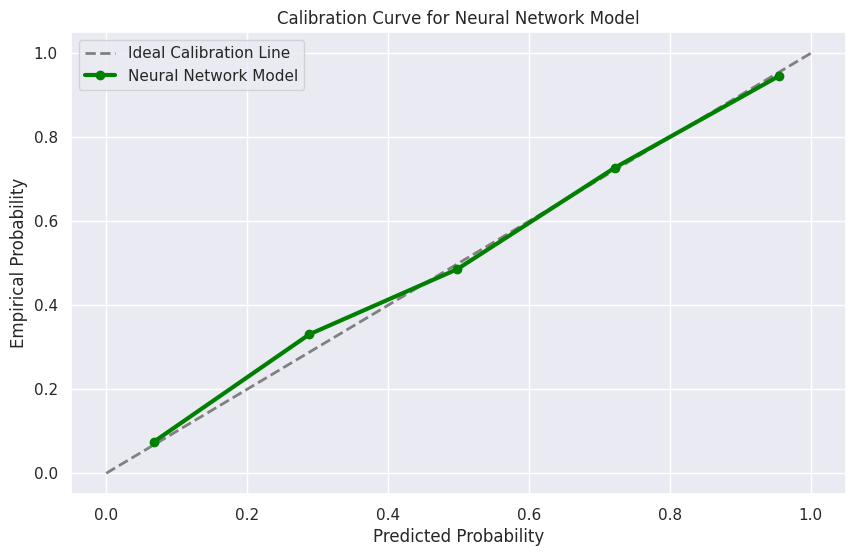

In [ ]:
# Calculate calibration data
prob_true, prob_pred = calibration_curve(y_test, nnm_y_prob_in_class_1_given_X, n_bins=5)

# Plot calibration curve
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line", linewidth=2)  # Diagonal ideal line
plt.plot(prob_pred, prob_true, marker='o', label="Neural Network Model", color="green", linewidth=3)

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Neural Network Model")
plt.legend()
plt.grid(True)
plt.savefig('nn.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
nnm_matcher_f = lambda x, y: 1 if x == y else 0
nnm_matched_ = np.array([nnm_matcher_f(nnm_y_pred[i], y_test[i]) for i in range(len(y_test))])

In [ ]:
fig, ax = plt.subplots(nrows=3,figsize=(10,8))
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=y_test.reshape(-1,), ax=ax[0])
ax[0].set_title("Test Data")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=nnm_y_pred.reshape(-1,), ax=ax[1])
ax[1].set_title("Predictions")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=nnm_matched_.reshape(-1,), ax=ax[2], palette="husl") ### Pink points are misclassified
ax[2].set_title("Visualizing Decision")
plt.tight_layout()

In [ ]:
plt.savefig('nnm_1.png', dpi=300, bbox_inches='tight')

# Support Vector Machine

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

##  Hyperparametrization

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],       # Regularization parameters
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],  # Kernel coefficients for non-linear kernels
    'kernel': ['rbf', 'poly']  # Different kernels
}

grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)
grid_search.fit(scaled_x_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best model found: ", grid_search.best_estimator_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

## Training

In [ ]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)

In [ ]:
svm.fit(scaled_x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(probability=True, random_state=42)

In [ ]:
svm_y_pred = svm.predict(scaled_x_test)
svm_y_pred

array([1, 1, 0, ..., 0, 0, 1])

In [ ]:
svm_y_prob = svm.predict_proba(scaled_x_test)
svm_y_prob

array([[0.02617145, 0.97382855],
       [0.04700338, 0.95299662],
       [0.75838564, 0.24161436],
       ...,
       [0.9296614 , 0.0703386 ],
       [0.93592021, 0.06407979],
       [0.00968042, 0.99031958]])

In [ ]:
svm_y_prob_in_class_1_given_X = svm_y_prob[:, 1]
svm_y_prob_in_class_1_given_X

array([0.97382855, 0.95299662, 0.24161436, ..., 0.0703386 , 0.06407979,
       0.99031958])

In [ ]:
calculate_metrics(y_test, svm_y_pred, svm_y_prob_in_class_1_given_X)

AUC: 0.935
Precision: 0.889
Recall: 0.915
F1-score: 0.902
Accuracy: 0.875


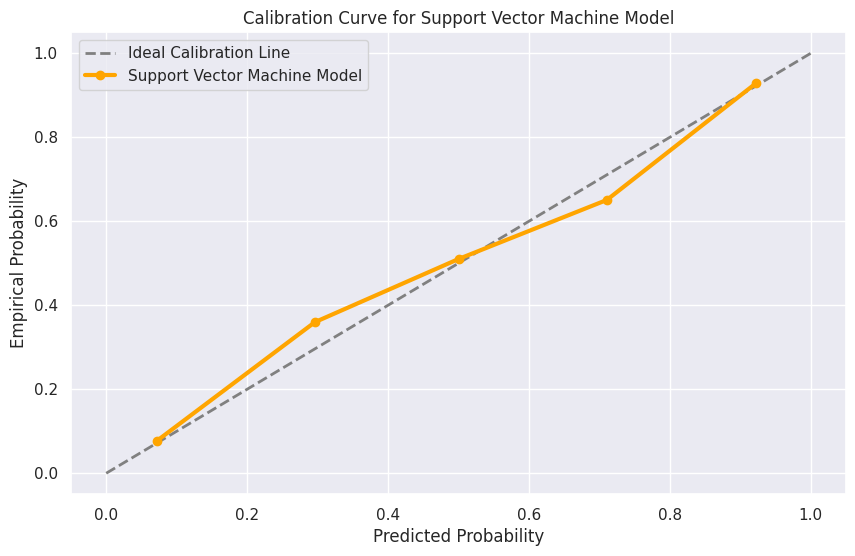

In [ ]:
# Calculate calibration data
prob_true, prob_pred = calibration_curve(y_test, svm_y_prob_in_class_1_given_X, n_bins=5)

# Plot calibration curve
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line", linewidth=2)  # Diagonal ideal line
plt.plot(prob_pred, prob_true, marker='o', label="Support Vector Machine Model", color="orange", linewidth=3)

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curve for Support Vector Machine Model")
plt.legend()
plt.grid(True)
plt.savefig('svm.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
svm_matcher_f = lambda x, y: 1 if x == y else 0
svm_matched_ = np.array([svm_matcher_f(svm_y_pred[i], y_test[i]) for i in range(len(y_test))])

In [ ]:
fig, ax = plt.subplots(nrows=3,figsize=(10,8))
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=y_test.reshape(-1,), ax=ax[0])
ax[0].set_title("Test Data")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=svm_y_pred.reshape(-1,), ax=ax[1])
ax[1].set_title("Predictions")
sns.scatterplot(x=x_transformed[:,0], y=x_transformed[:,1],hue=svm_matched_.reshape(-1,), ax=ax[2], palette="husl") ### Pink points are misclassified
ax[2].set_title("Visualizing Decision")
plt.tight_layout()

# Combined Calibration Curves

In [ ]:
sns.set_theme(style="darkgrid")

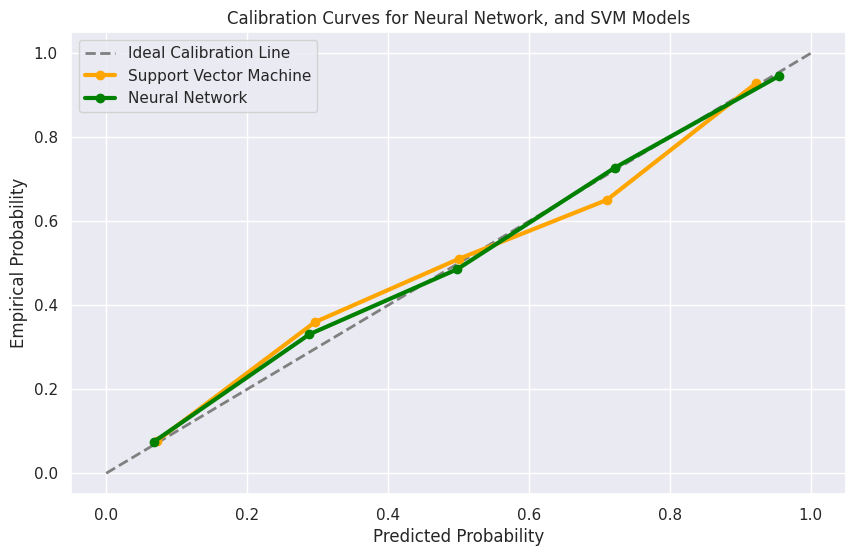

In [ ]:
# Calculate calibration data for each model
#prob_true_lr, prob_pred_lr = calibration_curve(y_test, lrm_y_prob_in_class_1_given_X, n_bins=5)
#prob_true_nb, prob_pred_nb = calibration_curve(y_test, gnb_y_prob_in_class_1_given_X, n_bins=5)
prob_true_svm, prob_pred_svm = calibration_curve(y_test, svm_y_prob_in_class_1_given_X, n_bins=5)
prob_true_nn, prob_pred_nn = calibration_curve(y_test, nnm_y_prob_in_class_1_given_X, n_bins=5)

# Plot calibration curves
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ideal Calibration Line", linewidth=2)  # Ideal diagonal line

# Plot each model's calibration curve
#plt.plot(prob_pred_lr, prob_true_lr, marker='o', label="Logistic Regression", color="red", linewidth=3)
#plt.plot(prob_pred_nb, prob_true_nb, marker='o', label="Naive Bayes", color="orange", linewidth=3)
plt.plot(prob_pred_svm, prob_true_svm, marker='o', label="Support Vector Machine", color="orange", linewidth=3)
plt.plot(prob_pred_nn, prob_true_nn, marker='o', label="Neural Network", color="green", linewidth=3)

# Labels and legend
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Probability")
plt.title("Calibration Curves for Neural Network, and SVM Models")
plt.legend()
plt.savefig('calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()
